# Rolling Replication

This notebook is a robustness check for AAPL and IBM across nine expanding-window test periods. In each fold, the HMM, scalers, lookback choice, threshold choice, and LSTM fits are redone using only information available up to that fold. The aim is to see whether the HMM feature helps repeatedly over time, not just in one fixed split.


## Imports and run settings


In [1]:
from __future__ import annotations

import json
import os
import sys
from datetime import datetime, timezone
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from hmmlearn.hmm import GaussianHMM
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    cohen_kappa_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.preprocessing import StandardScaler
from tensorflow import keras

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 180)
pd.set_option("display.width", 180)

TICKERS = ["AAPL", "IBM"]

ticker_colors = {
    "AAPL": "tab:blue",
    "IBM": "tab:orange",
    "MSFT": "tab:green",
}
INITIAL_TRAIN_WEEKS = 260
VALIDATION_WEEKS = 52
TEST_WEEKS = 52
STEP_WEEKS = 52
LOOKBACK_GRID = [4, 8, 12]
SEEDS = [7, 19, 42, 91, 123]
C_GRID = [0.01, 0.1, 1.0, 10.0]
THRESHOLD_GRID = np.round(np.arange(0.35, 0.651, 0.01), 2)
MAX_EPOCHS = 150
BATCH_SIZE = 32
PATIENCE = 12
EPS = 1e-6
N_HMM_STATES = 2
HMM_RANDOM_STATE = 42

np.random.seed(5)
tf.keras.utils.set_random_seed(5)


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    markers = [
        Path("outputs/weekly/model_df_weekly.parquet"),
        Path("outputs/weekly_context/model_df_weekly_with_vol_context.parquet"),
        Path("weekly_lstm_architecture.py"),
    ]
    for candidate in [start, *start.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {start}. Expected markers: {markers}")


PROJECT_ROOT = find_project_root()
os.chdir(PROJECT_ROOT)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

WEEKLY_SOURCE_PATH = PROJECT_ROOT / "outputs" / "weekly" / "model_df_weekly.parquet"
VOL_CONTEXT_SOURCE_PATH = PROJECT_ROOT / "outputs" / "weekly_context" / "model_df_weekly_with_vol_context.parquet"
WEEKLY_SCALED_PATH_FORBIDDEN = PROJECT_ROOT / "outputs" / "weekly" / "model_df_weekly_scaled.parquet"
OUTPUT_DIR = PROJECT_ROOT / "outputs" / "weekly_rolling_hmm_replication_aapl_ibm"
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"

SOURCE_AUDIT_PATHS = [
    PROJECT_ROOT / "LSTM_input_weekly.ipynb",
    PROJECT_ROOT / "hmm_regime_weekly.ipynb",
    PROJECT_ROOT / "weekly_context_lstm_training_qqq.ipynb",
    PROJECT_ROOT / "weekly_external_volatility_features.ipynb",
    PROJECT_ROOT / "weekly_lstm_architecture.py",
    WEEKLY_SOURCE_PATH,
    VOL_CONTEXT_SOURCE_PATH,
]
PROTECTED_SOURCE_PATHS = [
    PROJECT_ROOT / "LSTM_input_weekly.ipynb",
    PROJECT_ROOT / "hmm_regime_weekly.ipynb",
    PROJECT_ROOT / "weekly_hmm_informed_lstm.ipynb",
    PROJECT_ROOT / "weekly_context_lstm_training_qqq.ipynb",
    PROJECT_ROOT / "weekly_controlled_hmm_lstm_comparison.ipynb",
    PROJECT_ROOT / "weekly_hmm_robustness.ipynb",
    PROJECT_ROOT / "weekly_lstm_architecture.py",
]

for path in SOURCE_AUDIT_PATHS:
    if not path.exists():
        raise FileNotFoundError(f"Required source/audit file is missing: {path}")

protected_source_state = {
    str(path.relative_to(PROJECT_ROOT)): {"size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
    for path in PROTECTED_SOURCE_PATHS
}
existing_output_state = {
    str(path.relative_to(PROJECT_ROOT)): {"size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
    for path in (PROJECT_ROOT / "outputs").rglob("*")
    if path.is_file() and "weekly_rolling_hmm_replication_aapl_ibm" not in path.parts
}

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

from weekly_lstm_architecture import (  # noqa: E402
    WeeklyLSTMConfig,
    build_weekly_lstm_classifier,
    get_weekly_callbacks,
    set_global_seed,
)

LSTM_CONFIG = WeeklyLSTMConfig(
    lstm_units=(16,),
    dense_units=(8,),
    dropout=0.20,
    recurrent_dropout=0.00,
    learning_rate=1e-3,
)

print("Project root:", PROJECT_ROOT)
print("Using unscaled weekly source:", WEEKLY_SOURCE_PATH.relative_to(PROJECT_ROOT))
print("Using unscaled volatility source:", VOL_CONTEXT_SOURCE_PATH.relative_to(PROJECT_ROOT))
print("Forbidden fixed-split scaled source not used:", WEEKLY_SCALED_PATH_FORBIDDEN.relative_to(PROJECT_ROOT))


Project root: D:\BA_year_3\honour project
Using unscaled weekly source: outputs\weekly\model_df_weekly.parquet
Using unscaled volatility source: outputs\weekly_context\model_df_weekly_with_vol_context.parquet
Forbidden fixed-split scaled source not used: outputs\weekly\model_df_weekly_scaled.parquet


## Feature sets used in the rolling check

The paired comparison uses the same test observations within each ticker and fold. AAPL uses a technical plus VIX/VXN volatility-context base, while IBM uses a technical-only base; in both cases the HMM variant adds the fold-specific scaled HMM probability. QQQ, NBER, smoothed HMM, and future-looking columns are kept out of this replication.


In [3]:
TECHNICAL_FEATURES = [
    "Weekly_Log_Return",
    "Weekly_Open_Close_Log_Return",
    "Weekly_High_Low_Range",
    "Weekly_Volume_Change",
    "Rolling_Vol_4",
    "Rolling_Vol_12",
    "Rolling_Vol_26",
    "Momentum_4",
    "Momentum_12",
    "Momentum_26",
    "MA_Gap_4",
    "MA_Gap_12",
    "MA_Gap_26",
    "Drawdown_12",
    "Drawdown_26",
]

VOL_CONTEXT_FEATURES_COMPACT = [
    "VIX_Close",
    "VIX_Log_Change",
    "VIX_ZScore_12",
    "VIX_Above_MA_12",
    "VXN_Close",
    "VXN_Log_Change",
    "VXN_ZScore_12",
    "VXN_Above_MA_12",
    "VXN_minus_VIX",
    "VXN_to_VIX",
]

VARIANT_FEATURES = {
    "AAPL_Tech_Volatility": TECHNICAL_FEATURES + VOL_CONTEXT_FEATURES_COMPACT,
    "AAPL_Tech_Volatility_HMM": TECHNICAL_FEATURES + VOL_CONTEXT_FEATURES_COMPACT + ["HMM_Up_Prob_Scaled"],
    "IBM_Technical": TECHNICAL_FEATURES,
    "IBM_Technical_HMM": TECHNICAL_FEATURES + ["HMM_Up_Prob_Scaled"],
}

BASE_VARIANT_BY_TICKER = {
    "AAPL": "AAPL_Tech_Volatility",
    "IBM": "IBM_Technical",
}
HMM_VARIANT_BY_TICKER = {
    "AAPL": "AAPL_Tech_Volatility_HMM",
    "IBM": "IBM_Technical_HMM",
}

FEATURE_SOURCE_BY_GROUP = {
    "Technical": "LSTM_input_weekly.ipynb",
    "VIX/VXN": "weekly_context_lstm_training_qqq.ipynb",
    "HMM": "hmm_regime_weekly.ipynb (fold-specific refit in this notebook)",
}

FORBIDDEN_EXACT_FEATURES = {
    "Target_State_Binary",
    "Target_State",
    "Next_Week_Log_Return",
    "Target_Date",
    "HMM_Bullish_Prob_Next",
}
FORBIDDEN_SUBSTRINGS = ["QQQ", "Relative_", "NBER", "Macro", "Smoothed", "Future", "Forward", "Target", "Next_Week"]


def feature_group(feature: str) -> str:
    if feature in TECHNICAL_FEATURES:
        return "Technical"
    if feature in VOL_CONTEXT_FEATURES_COMPACT:
        return "VIX/VXN"
    if feature == "HMM_Up_Prob_Scaled":
        return "HMM"
    raise ValueError(f"Unknown feature group for {feature}")


def validate_feature_list(features: list[str], label: str) -> None:
    duplicated = pd.Series(features)[pd.Series(features).duplicated()].tolist()
    if duplicated:
        raise ValueError(f"{label} has duplicate features: {duplicated}")
    exact = sorted(set(features).intersection(FORBIDDEN_EXACT_FEATURES))
    if exact:
        raise ValueError(f"{label} contains forbidden features: {exact}")
    pattern_hits = [col for col in features if any(token.lower() in col.lower() for token in FORBIDDEN_SUBSTRINGS)]
    if pattern_hits:
        raise ValueError(f"{label} contains target-like, future-looking, QQQ, NBER, macro, or smoothed features: {pattern_hits}")
    hmm_cols = [col for col in features if col.startswith("HMM_")]
    if hmm_cols and hmm_cols != ["HMM_Up_Prob_Scaled"]:
        raise ValueError(f"{label} contains invalid HMM features: {hmm_cols}")


for variant, features in VARIANT_FEATURES.items():
    validate_feature_list(features, variant)

feature_audit_rows = []
for ticker, variants in {"AAPL": ["AAPL_Tech_Volatility", "AAPL_Tech_Volatility_HMM"], "IBM": ["IBM_Technical", "IBM_Technical_HMM"]}.items():
    for variant in variants:
        for feature in VARIANT_FEATURES[variant]:
            group = feature_group(feature)
            feature_audit_rows.append(
                {
                    "Ticker": ticker,
                    "Variant": variant,
                    "Feature_Group": group,
                    "Feature_Name": feature,
                    "Source_File": FEATURE_SOURCE_BY_GROUP[group],
                    "Used_In_Model": True,
                }
            )

rolling_feature_audit = pd.DataFrame(feature_audit_rows)
rolling_feature_audit.to_csv(OUTPUT_DIR / "rolling_feature_audit.csv", index=False)
display(rolling_feature_audit)


,Ticker,Variant,Feature_Group,Feature_Name,Source_File,Used_In_Model
0,AAPL,AAPL_Tech_Volatility,Technical,Weekly_Log_Return,LSTM_input_weekly.ipynb,True
1,AAPL,AAPL_Tech_Volatility,Technical,Weekly_Open_Close_Log_Return,LSTM_input_weekly.ipynb,True
2,AAPL,AAPL_Tech_Volatility,Technical,Weekly_High_Low_Range,LSTM_input_weekly.ipynb,True
3,AAPL,AAPL_Tech_Volatility,Technical,Weekly_Volume_Change,LSTM_input_weekly.ipynb,True
4,AAPL,AAPL_Tech_Volatility,Technical,Rolling_Vol_4,LSTM_input_weekly.ipynb,True
...,...,...,...,...,...,...
77,IBM,IBM_Technical_HMM,Technical,MA_Gap_12,LSTM_input_weekly.ipynb,True
78,IBM,IBM_Technical_HMM,Technical,MA_Gap_26,LSTM_input_weekly.ipynb,True
79,IBM,IBM_Technical_HMM,Technical,Drawdown_12,LSTM_input_weekly.ipynb,True
80,IBM,IBM_Technical_HMM,Technical,Drawdown_26,LSTM_input_weekly.ipynb,True


## Load unscaled inputs and validate target


In [4]:
REQUIRED_WEEKLY_COLUMNS = [
    "Ticker",
    "Date",
    "Target_Date",
    "Split",
    "Weekly_Log_Return",
    "Next_Week_Log_Return",
    "Target_State_Binary",
    "Target_State",
] + TECHNICAL_FEATURES

weekly_source_df = pd.read_parquet(WEEKLY_SOURCE_PATH).copy()
vol_context_df = pd.read_parquet(VOL_CONTEXT_SOURCE_PATH).copy()

for label, df in [("weekly_source_df", weekly_source_df), ("vol_context_df", vol_context_df)]:
    for col in ["Date", "Target_Date"]:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col])

missing_weekly = [col for col in REQUIRED_WEEKLY_COLUMNS if col not in weekly_source_df.columns]
if missing_weekly:
    raise ValueError(f"Unscaled weekly source is missing required columns: {missing_weekly}")

missing_vol = [col for col in VOL_CONTEXT_FEATURES_COMPACT if col not in vol_context_df.columns]
if missing_vol:
    raise ValueError(f"VIX/VXN data cannot be found. Missing columns: {missing_vol}")

weekly_source_df = weekly_source_df.loc[weekly_source_df["Ticker"].isin(TICKERS)].copy()
if sorted(weekly_source_df["Ticker"].unique().tolist()) != TICKERS:
    raise ValueError("The source dataframe does not contain exactly AAPL and IBM after filtering.")
if "MSFT" in weekly_source_df["Ticker"].unique():
    raise ValueError("MSFT entered the rolling replication source data.")

if not weekly_source_df["Target_State_Binary"].dropna().isin([0, 1]).all():
    raise ValueError("Target_State_Binary must contain only 0 and 1.")
weekly_source_df["Target_State_Binary"] = weekly_source_df["Target_State_Binary"].astype(int)

if not (weekly_source_df["Target_Date"] > weekly_source_df["Date"]).all():
    raise ValueError("Every Target_Date must be strictly later than Date.")

for ticker, group in weekly_source_df.groupby("Ticker", sort=True):
    if group["Date"].duplicated().any():
        raise ValueError(f"{ticker} has duplicate Date values.")
    if group["Target_Date"].duplicated().any():
        raise ValueError(f"{ticker} has duplicate Target_Date values.")
    if group["Weekly_Log_Return"].isna().any():
        raise ValueError(f"{ticker} has missing Weekly_Log_Return values.")

merge_keys = ["Ticker", "Date", "Target_Date", "Split"]
if weekly_source_df.duplicated(merge_keys).any():
    raise ValueError("Unscaled weekly source has duplicate merge keys.")
if vol_context_df.duplicated(merge_keys).any():
    raise ValueError("Volatility context source has duplicate merge keys.")

vol_for_merge = vol_context_df[merge_keys + VOL_CONTEXT_FEATURES_COMPACT].copy()
model_df = weekly_source_df.merge(vol_for_merge, on=merge_keys, how="left", validate="one_to_one")
if model_df.columns.duplicated().any():
    raise ValueError(f"Duplicate columns were introduced: {model_df.columns[model_df.columns.duplicated()].tolist()}")

model_df = model_df.sort_values(["Ticker", "Date"]).reset_index(drop=True)
print("Merged rolling source shape:", model_df.shape)
display(model_df.groupby("Ticker").size().rename("rows").reset_index())


Merged rolling source shape: (1616, 39)


,Ticker,rows
0,AAPL,808
1,IBM,808


## Build expanding-window folds


In [5]:
def variant_base_features_for_ticker(ticker: str) -> list[str]:
    return VARIANT_FEATURES[BASE_VARIANT_BY_TICKER[ticker]]


def clean_ticker_source(ticker: str) -> pd.DataFrame:
    features = variant_base_features_for_ticker(ticker)
    required = ["Ticker", "Date", "Target_Date", "Weekly_Log_Return", "Target_State_Binary", "Next_Week_Log_Return"] + features
    out = model_df.loc[model_df["Ticker"] == ticker].sort_values("Date").copy()
    before = len(out)
    out = out.dropna(subset=required).reset_index(drop=True)
    if out.empty:
        raise ValueError(f"No usable rows remain for {ticker}.")
    if not np.isfinite(out[features + ["Weekly_Log_Return"]].to_numpy(dtype=float)).all():
        raise ValueError(f"{ticker} has non-finite source features before fold-specific preprocessing.")
    print(f"{ticker}: retained {len(out)} of {before} rows after variant-specific source filtering.")
    return out


ticker_sources = {ticker: clean_ticker_source(ticker) for ticker in TICKERS}


def build_expanding_folds(ticker: str, df_ticker: pd.DataFrame) -> tuple[list[dict], pd.DataFrame]:
    rows = []
    fold_slices = []
    fold = 1
    offset = 0
    n_rows = len(df_ticker)
    # Each fold keeps the past as training, then uses the next 52 weeks
    # for validation and the following 52 weeks for testing.
    while offset + INITIAL_TRAIN_WEEKS + VALIDATION_WEEKS + TEST_WEEKS <= n_rows:
        train_start = 0
        train_end = offset + INITIAL_TRAIN_WEEKS
        val_start = train_end
        val_end = val_start + VALIDATION_WEEKS
        test_start = val_end
        test_end = test_start + TEST_WEEKS

        train = df_ticker.iloc[train_start:train_end]
        validation = df_ticker.iloc[val_start:val_end]
        test = df_ticker.iloc[test_start:test_end]

        if not (train["Target_Date"].max() < validation["Target_Date"].min()):
            raise ValueError(f"{ticker} fold {fold}: training target dates do not precede validation target dates.")
        if not (validation["Target_Date"].max() < test["Target_Date"].min()):
            raise ValueError(f"{ticker} fold {fold}: validation target dates do not precede test target dates.")

        for split_name, split_df in [("validation", validation), ("test", test)]:
            if split_df["Target_State_Binary"].nunique() < 2:
                raise ValueError(f"{ticker} fold {fold}: {split_name} block lacks both classes.")

        rows.append(
            {
                "Ticker": ticker,
                "Fold": fold,
                "Train_Start_Date": train["Date"].min(),
                "Train_End_Date": train["Date"].max(),
                "Validation_Start_Date": validation["Date"].min(),
                "Validation_End_Date": validation["Date"].max(),
                "Test_Start_Date": test["Date"].min(),
                "Test_End_Date": test["Date"].max(),
                "n_Train": int(len(train)),
                "n_Validation": int(len(validation)),
                "n_Test": int(len(test)),
                "Train_Up_Share": float(train["Target_State_Binary"].mean()),
                "Validation_Up_Share": float(validation["Target_State_Binary"].mean()),
                "Test_Up_Share": float(test["Target_State_Binary"].mean()),
                "train_slice": (train_start, train_end),
                "validation_slice": (val_start, val_end),
                "test_slice": (test_start, test_end),
            }
        )
        fold_slices.append({"Ticker": ticker, "Fold": fold, "train": (train_start, train_end), "validation": (val_start, val_end), "test": (test_start, test_end)})
        fold += 1
        offset += STEP_WEEKS

    fold_definitions = pd.DataFrame(rows)
    if fold_definitions.empty:
        raise ValueError(f"No complete rolling folds could be created for {ticker}.")

    test_ranges = []
    for row in fold_definitions.itertuples(index=False):
        current = pd.date_range(row.Test_Start_Date, row.Test_End_Date, freq="D")
        overlap = set(current).intersection(set().union(*test_ranges)) if test_ranges else set()
        if overlap:
            raise ValueError(f"{ticker} has overlapping test dates across folds.")
        test_ranges.append(set(current))

    return fold_slices, fold_definitions.drop(columns=["train_slice", "validation_slice", "test_slice"])


fold_slice_lookup = {}
fold_definition_frames = []
for ticker in TICKERS:
    slices, defs = build_expanding_folds(ticker, ticker_sources[ticker])
    for item in slices:
        fold_slice_lookup[(item["Ticker"], item["Fold"])] = item
    fold_definition_frames.append(defs)

rolling_fold_definitions = pd.concat(fold_definition_frames, ignore_index=True)
rolling_fold_definitions.to_csv(OUTPUT_DIR / "rolling_fold_definitions.csv", index=False)
display(rolling_fold_definitions)


AAPL: retained 797 of 808 rows after variant-specific source filtering.
IBM: retained 808 of 808 rows after variant-specific source filtering.


,Ticker,Fold,Train_Start_Date,Train_End_Date,Validation_Start_Date,Validation_End_Date,Test_Start_Date,Test_End_Date,n_Train,n_Validation,n_Test,Train_Up_Share,Validation_Up_Share,Test_Up_Share
0,AAPL,1,2010-09-24,2015-09-11,2015-09-18,2016-09-09,2016-09-16,2017-09-08,260,52,52,0.546154,0.538462,0.692308
1,AAPL,2,2010-09-24,2016-09-09,2016-09-16,2017-09-08,2017-09-15,2018-09-07,312,52,52,0.544872,0.692308,0.634615
2,AAPL,3,2010-09-24,2017-09-08,2017-09-15,2018-09-07,2018-09-14,2019-09-06,364,52,52,0.565934,0.634615,0.519231
3,AAPL,4,2010-09-24,2018-09-07,2018-09-14,2019-09-06,2019-09-13,2020-09-04,416,52,52,0.574519,0.519231,0.730769
4,AAPL,5,2010-09-24,2019-09-06,2019-09-13,2020-09-04,2020-09-11,2021-09-03,468,52,52,0.568376,0.730769,0.596154
5,AAPL,6,2010-09-24,2020-09-04,2020-09-11,2021-09-03,2021-09-10,2022-09-02,520,52,52,0.584615,0.596154,0.480769
6,AAPL,7,2010-09-24,2021-09-03,2021-09-10,2022-09-02,2022-09-09,2023-09-01,572,52,52,0.585664,0.480769,0.557692
7,AAPL,8,2010-09-24,2022-09-02,2022-09-09,2023-09-01,2023-09-08,2024-08-30,624,52,52,0.576923,0.557692,0.576923
8,AAPL,9,2010-09-24,2023-09-01,2023-09-08,2024-08-30,2024-09-06,2025-08-29,676,52,52,0.575444,0.576923,0.557692
9,IBM,1,2010-07-09,2015-06-26,2015-07-03,2016-06-24,2016-07-01,2017-06-23,260,52,52,0.542308,0.480769,0.442308


## Refit HMM and scalers inside each fold

The HMM and all scalers are fit again for every fold. This is slower, but it keeps each fold closer to a real forecasting setup where later data is not known yet.


In [6]:
def logsumexp_np(values: np.ndarray, axis: int | None = None) -> np.ndarray:
    values = np.asarray(values, dtype=float)
    max_values = np.max(values, axis=axis, keepdims=True)
    result = max_values + np.log(np.sum(np.exp(values - max_values), axis=axis, keepdims=True))
    if axis is not None:
        result = np.squeeze(result, axis=axis)
    return result


def filtered_state_probabilities(model: GaussianHMM, X: np.ndarray) -> np.ndarray:
    """Return causal filtered probabilities P(S_t | Y_1:t), not smoothed probabilities."""
    X = np.asarray(X, dtype=float)
    log_likelihood = model._compute_log_likelihood(X)
    eps = np.finfo(float).tiny
    log_startprob = np.log(np.clip(model.startprob_, eps, 1.0))
    log_transmat = np.log(np.clip(model.transmat_, eps, 1.0))
    log_alpha = np.empty_like(log_likelihood)
    log_alpha[0] = log_startprob + log_likelihood[0]
    log_alpha[0] -= logsumexp_np(log_alpha[0])
    for t in range(1, len(X)):
        log_pred = logsumexp_np(log_alpha[t - 1][:, None] + log_transmat, axis=0)
        log_alpha[t] = log_pred + log_likelihood[t]
        log_alpha[t] -= logsumexp_np(log_alpha[t])
    probs = np.exp(log_alpha)
    probs /= probs.sum(axis=1, keepdims=True)
    return probs


def fit_fold_hmm_and_features(ticker: str, fold: int, fold_raw: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    train_mask = fold_raw["Fold_Split"].eq("train").to_numpy()
    if train_mask.sum() < 50:
        raise ValueError(f"{ticker} fold {fold}: too few training rows for HMM.")

    hmm_scaler = StandardScaler()
    X_train = fold_raw.loc[train_mask, ["Weekly_Log_Return"]].to_numpy(dtype=float)
    X_all = fold_raw[["Weekly_Log_Return"]].to_numpy(dtype=float)
    # Fit the HMM observation scaler on fold-training rows only.
    hmm_scaler.fit(X_train)
    X_train_scaled = hmm_scaler.transform(X_train)
    X_all_scaled = hmm_scaler.transform(X_all)

    hmm = GaussianHMM(
        n_components=N_HMM_STATES,
        covariance_type="full",
        n_iter=500,
        tol=1e-4,
        random_state=HMM_RANDOM_STATE,
        min_covar=1e-4,
    )
    hmm.fit(X_train_scaled)
    # Filtered probabilities use observations through the current week only.
    filtered_probs = filtered_state_probabilities(hmm, X_all_scaled)
    # Convert current-state probabilities into one-week-ahead probabilities.
    next_probs = filtered_probs @ hmm.transmat_
    hard_states = filtered_probs.argmax(axis=1)

    train_states = hard_states[train_mask]
    train_labels = fold_raw.loc[train_mask, "Target_State_Binary"].to_numpy(dtype=int)
    state_up_rates = {}
    state_mean_returns = {}
    for state in range(N_HMM_STATES):
        state_mask = train_states == state
        if state_mask.any():
            state_up_rates[state] = float(train_labels[state_mask].mean())
            state_mean_returns[state] = float(fold_raw.loc[train_mask, "Weekly_Log_Return"].to_numpy(dtype=float)[state_mask].mean())
        else:
            state_up_rates[state] = 0.5
            state_mean_returns[state] = np.nan

    hmm_up_prob_raw = next_probs[:, 0] * state_up_rates[0] + next_probs[:, 1] * state_up_rates[1]
    out = fold_raw.copy()
    out["HMM_State_Filtered"] = hard_states.astype(int)
    out["HMM_Up_Prob_Raw"] = hmm_up_prob_raw
    if out["HMM_Up_Prob_Raw"].isna().any() or not out["HMM_Up_Prob_Raw"].between(0, 1).all():
        raise ValueError(f"{ticker} fold {fold}: invalid raw HMM probabilities.")

    hmm_feature_scaler = StandardScaler()
    hmm_feature_scaler.fit(out.loc[out["Fold_Split"].eq("train"), ["HMM_Up_Prob_Raw"]])
    out["HMM_Up_Prob_Scaled"] = hmm_feature_scaler.transform(out[["HMM_Up_Prob_Raw"]]).reshape(-1)
    if out["HMM_Up_Prob_Scaled"].isna().any():
        raise ValueError(f"{ticker} fold {fold}: missing scaled HMM probabilities.")

    diagnostics = {
        "Ticker": ticker,
        "Fold": fold,
        "HMM_Train_Start_Date": out.loc[out["Fold_Split"].eq("train"), "Date"].min(),
        "HMM_Train_End_Date": out.loc[out["Fold_Split"].eq("train"), "Date"].max(),
        "State_0_Train_Mean_Return": state_mean_returns[0],
        "State_1_Train_Mean_Return": state_mean_returns[1],
        "State_0_Train_Up_Rate": state_up_rates[0],
        "State_1_Train_Up_Rate": state_up_rates[1],
        "Transition_00": float(hmm.transmat_[0, 0]),
        "Transition_01": float(hmm.transmat_[0, 1]),
        "Transition_10": float(hmm.transmat_[1, 0]),
        "Transition_11": float(hmm.transmat_[1, 1]),
        "HMM_Up_Prob_Train_Mean": float(out.loc[out["Fold_Split"].eq("train"), "HMM_Up_Prob_Raw"].mean()),
        "HMM_Up_Prob_Validation_Mean": float(out.loc[out["Fold_Split"].eq("validation"), "HMM_Up_Prob_Raw"].mean()),
        "HMM_Up_Prob_Test_Mean": float(out.loc[out["Fold_Split"].eq("test"), "HMM_Up_Prob_Raw"].mean()),
        "HMM_Up_Prob_Test_SD": float(out.loc[out["Fold_Split"].eq("test"), "HMM_Up_Prob_Raw"].std()),
        "Probability_Type": "filtered_not_smoothed",
        "HMM_Fitted_On": "fold_train_only",
        "State_Up_Rates_Estimated_On": "fold_train_labels_only",
    }
    return out, diagnostics


def add_fold_split(df_ticker: pd.DataFrame, fold_info: dict) -> pd.DataFrame:
    parts = []
    for split in ["train", "validation", "test"]:
        start, end = fold_info[split]
        part = df_ticker.iloc[start:end].copy()
        part["Fold_Split"] = split
        parts.append(part)
    out = pd.concat(parts, ignore_index=True).sort_values("Date").reset_index(drop=True)
    return out


def scale_fold_features(ticker: str, fold: int, fold_with_hmm: pd.DataFrame) -> tuple[pd.DataFrame, list[dict]]:
    base_features = variant_base_features_for_ticker(ticker)
    prepared = fold_with_hmm.copy()
    scale_features = base_features.copy()
    train_mask = prepared["Fold_Split"].eq("train")

    scaler = StandardScaler()
    # Feature scalers are also fit inside the fold on training rows only.
    scaler.fit(prepared.loc[train_mask, scale_features])
    prepared.loc[:, scale_features] = scaler.transform(prepared[scale_features])

    diagnostic_rows = []
    for feature in scale_features + ["HMM_Up_Prob_Scaled"]:
        raw_col = "HMM_Up_Prob_Raw" if feature == "HMM_Up_Prob_Scaled" else feature
        for split in ["train", "validation", "test"]:
            split_mask = prepared["Fold_Split"].eq(split)
            raw_values = fold_with_hmm.loc[split_mask, raw_col].to_numpy(dtype=float)
            scaled_values = prepared.loc[split_mask, feature].to_numpy(dtype=float)
            diagnostic_rows.append(
                {
                    "Ticker": ticker,
                    "Fold": fold,
                    "Split": split,
                    "Feature": feature,
                    "Raw_Mean": float(np.mean(raw_values)),
                    "Raw_SD": float(np.std(raw_values, ddof=1)),
                    "Raw_Min": float(np.min(raw_values)),
                    "Raw_Max": float(np.max(raw_values)),
                    "Scaled_Mean": float(np.mean(scaled_values)),
                    "Scaled_SD": float(np.std(scaled_values, ddof=1)),
                    "Scaled_Min": float(np.min(scaled_values)),
                    "Scaled_Max": float(np.max(scaled_values)),
                    "Scaler_Fitted_On": "fold_train_only",
                }
            )

    required_for_ticker = sorted(set(VARIANT_FEATURES[BASE_VARIANT_BY_TICKER[ticker]] + VARIANT_FEATURES[HMM_VARIANT_BY_TICKER[ticker]]))
    if not np.isfinite(prepared[required_for_ticker].to_numpy(dtype=float)).all():
        raise ValueError(f"{ticker} fold {fold}: non-finite values after fold-specific preprocessing.")
    return prepared, diagnostic_rows


prepared_fold_data = {}
hmm_diagnostic_rows = []
scaling_diagnostic_rows = []

for ticker in TICKERS:
    source = ticker_sources[ticker]
    for fold in sorted(rolling_fold_definitions.loc[rolling_fold_definitions["Ticker"].eq(ticker), "Fold"].unique()):
        fold_raw = add_fold_split(source, fold_slice_lookup[(ticker, fold)])
        fold_with_hmm, hmm_diag = fit_fold_hmm_and_features(ticker, int(fold), fold_raw)
        prepared, scale_diag = scale_fold_features(ticker, int(fold), fold_with_hmm)
        prepared_fold_data[(ticker, int(fold))] = prepared
        hmm_diagnostic_rows.append(hmm_diag)
        scaling_diagnostic_rows.extend(scale_diag)

rolling_hmm_fold_diagnostics = pd.DataFrame(hmm_diagnostic_rows)
rolling_feature_scaling_diagnostics = pd.DataFrame(scaling_diagnostic_rows)
rolling_hmm_fold_diagnostics.to_csv(OUTPUT_DIR / "rolling_hmm_fold_diagnostics.csv", index=False)
rolling_feature_scaling_diagnostics.to_csv(OUTPUT_DIR / "rolling_feature_scaling_diagnostics.csv", index=False)

display(rolling_hmm_fold_diagnostics.head())
display(rolling_feature_scaling_diagnostics.head())


,Ticker,Fold,HMM_Train_Start_Date,HMM_Train_End_Date,State_0_Train_Mean_Return,State_1_Train_Mean_Return,State_0_Train_Up_Rate,State_1_Train_Up_Rate,Transition_00,Transition_01,Transition_10,Transition_11,HMM_Up_Prob_Train_Mean,HMM_Up_Prob_Validation_Mean,HMM_Up_Prob_Test_Mean,HMM_Up_Prob_Test_SD,Probability_Type,HMM_Fitted_On,State_Up_Rates_Estimated_On
0,AAPL,1,2010-09-24,2015-09-11,-0.000886,0.074857,0.549587,0.500000,0.801560,0.198440,0.999699,3.012925e-04,0.541394,0.541183,0.541291,0.001268,filtered_not_smoothed,fold_train_only,fold_train_labels_only
1,AAPL,2,2010-09-24,2016-09-09,0.005738,-0.099723,0.540984,0.714286,0.872379,0.127621,0.999828,1.722750e-04,0.560605,0.561303,0.560890,0.001898,filtered_not_smoothed,fold_train_only,fold_train_labels_only
2,AAPL,3,2010-09-24,2017-09-08,0.008521,0.001957,0.583333,0.557377,0.914735,0.085265,0.049640,9.503595e-01,0.566617,0.567716,0.566791,0.006114,filtered_not_smoothed,fold_train_only,fold_train_labels_only
3,AAPL,4,2010-09-24,2018-09-07,0.003455,0.106116,0.577670,0.250000,0.977564,0.022436,1.000000,6.755384e-64,0.570495,0.570421,0.570662,0.001032,filtered_not_smoothed,fold_train_only,fold_train_labels_only
4,AAPL,5,2010-09-24,2019-09-06,0.001114,0.088127,0.569536,0.533333,0.797099,0.202901,0.999821,1.787303e-04,0.563432,0.563739,0.563433,0.000994,filtered_not_smoothed,fold_train_only,fold_train_labels_only


,Ticker,Fold,Split,Feature,Raw_Mean,Raw_SD,Raw_Min,Raw_Max,Scaled_Mean,Scaled_SD,Scaled_Min,Scaled_Max,Scaler_Fitted_On
0,AAPL,1,train,Weekly_Log_Return,0.004357,0.038115,-0.128106,0.132043,-5.124106e-18,1.001929,-3.482087,3.356492,fold_train_only
1,AAPL,1,validation,Weekly_Log_Return,-0.001556,0.038423,-0.119891,0.069905,-1.554378e-01,1.010035,-3.266126,1.723053,fold_train_only
2,AAPL,1,test,Weekly_Log_Return,0.008617,0.026440,-0.046086,0.108246,1.119643e-01,0.695033,-1.326001,2.730929,fold_train_only
3,AAPL,1,train,Weekly_Open_Close_Log_Return,0.002854,0.038266,-0.137185,0.177443,-3.416071e-18,1.001929,-3.666644,4.571300,fold_train_only
4,AAPL,1,validation,Weekly_Open_Close_Log_Return,-0.001729,0.036193,-0.113435,0.072069,-1.199772e-01,0.947648,-3.044806,1.812266,fold_train_only


## Build fold-level sequences


In [7]:
def create_sequences_for_fold(ticker: str, fold: int, variant: str, lookback: int) -> tuple[dict[str, tuple[np.ndarray, np.ndarray, pd.DataFrame]], dict]:
    df = prepared_fold_data[(ticker, fold)].sort_values("Date").reset_index(drop=True)
    features = VARIANT_FEATURES[variant]
    contains_hmm = "HMM_Up_Prob_Scaled" in features
    if "HMM_Up_Prob_Raw" in features:
        raise ValueError("Raw HMM probabilities must not enter LSTM feature matrices.")
    validate_feature_list(features, variant)
    X_by_split = {"train": [], "validation": [], "test": []}
    y_by_split = {"train": [], "validation": [], "test": []}
    meta_by_split = {"train": [], "validation": [], "test": []}

    for i in range(lookback - 1, len(df)):
        seq = df.iloc[i - lookback + 1 : i + 1]
        target_row = df.iloc[i]
        split = target_row["Fold_Split"]
        X_seq = seq[features].to_numpy(dtype=np.float32)
        y_value = int(target_row["Target_State_Binary"])
        if X_seq.shape != (lookback, len(features)):
            raise ValueError(f"{ticker} fold {fold} {variant} lookback {lookback}: sequence shape mismatch.")
        if not np.isfinite(X_seq).all():
            raise ValueError(f"{ticker} fold {fold} {variant} lookback {lookback}: sequence has non-finite values.")
        if target_row["Target_Date"] <= seq["Date"].max():
            raise ValueError(f"{ticker} fold {fold}: sequence uses rows at or after Target_Date.")
        # The split comes from the target row; older rows in the window
        # would already be known at that fold's prediction date.
        X_by_split[split].append(X_seq)
        y_by_split[split].append(y_value)
        meta_by_split[split].append(
            {
                "Ticker": ticker,
                "Fold": fold,
                "Variant": variant,
                "Lookback": lookback,
                "Split": split,
                "Date": target_row["Date"],
                "Target_Date": target_row["Target_Date"],
                "Target_State_Binary": y_value,
            }
        )

    out = {}
    diag_rows = []
    for split in ["train", "validation", "test"]:
        X = np.asarray(X_by_split[split], dtype=np.float32)
        y = np.asarray(y_by_split[split], dtype=np.int64)
        meta = pd.DataFrame(meta_by_split[split])
        if len(y) == 0:
            raise ValueError(f"{ticker} fold {fold} {variant} lookback {lookback}: no {split} sequences.")
        if split in ["validation", "test"] and len(np.unique(y)) < 2:
            raise ValueError(f"{ticker} fold {fold} {variant} lookback {lookback}: {split} sequences lack both classes.")
        out[split] = (X, y, meta)
        diag_rows.append(
            {
                "Ticker": ticker,
                "Fold": fold,
                "Variant": variant,
                "Lookback": lookback,
                "Split": split,
                "n_Sequences": int(len(y)),
                "n_Up": int((y == 1).sum()),
                "n_Down": int((y == 0).sum()),
                "Feature_Count": int(len(features)),
                "Contains_HMM": bool(contains_hmm),
            }
        )
    return out, diag_rows


sequence_store = {}
sequence_diagnostic_rows = []
for ticker in TICKERS:
    variants = [BASE_VARIANT_BY_TICKER[ticker], HMM_VARIANT_BY_TICKER[ticker]]
    folds = sorted(rolling_fold_definitions.loc[rolling_fold_definitions["Ticker"].eq(ticker), "Fold"].unique())
    for fold in folds:
        for variant in variants:
            for lookback in LOOKBACK_GRID:
                seqs, diags = create_sequences_for_fold(ticker, int(fold), variant, lookback)
                sequence_store[(ticker, int(fold), variant, lookback)] = seqs
                sequence_diagnostic_rows.extend(diags)

rolling_sequence_diagnostics = pd.DataFrame(sequence_diagnostic_rows)
rolling_sequence_diagnostics.to_csv(OUTPUT_DIR / "rolling_sequence_diagnostics.csv", index=False)
display(rolling_sequence_diagnostics.head())


,Ticker,Fold,Variant,Lookback,Split,n_Sequences,n_Up,n_Down,Feature_Count,Contains_HMM
0,AAPL,1,AAPL_Tech_Volatility,4,train,257,140,117,25,False
1,AAPL,1,AAPL_Tech_Volatility,4,validation,52,28,24,25,False
2,AAPL,1,AAPL_Tech_Volatility,4,test,52,36,16,25,False
3,AAPL,1,AAPL_Tech_Volatility,8,train,253,139,114,25,False
4,AAPL,1,AAPL_Tech_Volatility,8,validation,52,28,24,25,False


## Metrics and threshold helpers


In [8]:
def probability_metrics(y_true, y_prob, threshold: float) -> dict[str, float]:
    y_true = np.asarray(y_true).reshape(-1).astype(int)
    y_prob = np.asarray(y_prob).reshape(-1).astype(float)
    if len(y_true) != len(y_prob):
        raise ValueError("Metric arrays have different lengths.")
    if len(y_true) == 0:
        raise ValueError("Cannot evaluate empty arrays.")
    if not set(np.unique(y_true)).issubset({0, 1}):
        raise ValueError(f"Targets must be binary 0/1. Found {np.unique(y_true)}")
    if not np.isfinite(y_prob).all() or (y_prob < 0).any() or (y_prob > 1).any():
        raise ValueError("Probabilities must be finite and in [0, 1].")
    y_pred = (y_prob >= threshold).astype(int)
    p_clip = np.clip(y_prob, EPS, 1 - EPS)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    return {
        "ROC_AUC": float(roc_auc_score(y_true, y_prob)) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": float(average_precision_score(y_true, y_prob)) if int((y_true == 1).sum()) > 0 else np.nan,
        "Accuracy": float(accuracy_score(y_true, y_pred)),
        "Balanced_Accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "Precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "Recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "F1": float(f1_score(y_true, y_pred, zero_division=0)),
        "Cohen_Kappa": float(cohen_kappa_score(y_true, y_pred)),
        "Brier_Score": float(brier_score_loss(y_true, y_prob)),
        "Log_Loss": float(log_loss(y_true, p_clip, labels=[0, 1])),
        "Decision_Threshold": float(threshold),
        "Share_Predicted_Up": float(np.mean(y_pred)),
        "Share_Actual_Up": float(np.mean(y_true)),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


def select_threshold(y_validation, p_validation) -> float:
    rows = []
    y_validation = np.asarray(y_validation).astype(int)
    p_validation = np.asarray(p_validation).astype(float)
    for threshold in THRESHOLD_GRID:
        y_pred = (p_validation >= threshold).astype(int)
        rows.append(
            {
                "threshold": float(threshold),
                "balanced_accuracy": float(balanced_accuracy_score(y_validation, y_pred)),
                "distance": float(abs(threshold - 0.50)),
            }
        )
    best = pd.DataFrame(rows).sort_values(["balanced_accuracy", "distance", "threshold"], ascending=[False, True, True]).iloc[0]
    return float(best["threshold"])


def metrics_row(prefix: str, metrics: dict[str, float]) -> dict[str, float]:
    return {f"{prefix}_{key}": value for key, value in metrics.items()}


## Train seed models inside each fold

Each fold trains the base and HMM variants over the lookback grid and the same five seeds. Validation results are saved first, because lookback and threshold choices are made before looking at fold-test performance.


In [9]:
lstm_seed_rows = []
lstm_validation_prediction_frames = []

# The base and HMM variants use the same folds, lookbacks, and seeds.
for ticker in TICKERS:
    variants = [BASE_VARIANT_BY_TICKER[ticker], HMM_VARIANT_BY_TICKER[ticker]]
    folds = sorted(rolling_fold_definitions.loc[rolling_fold_definitions["Ticker"].eq(ticker), "Fold"].unique())
    for fold in folds:
        for lookback in LOOKBACK_GRID:
            for variant in variants:
                features = VARIANT_FEATURES[variant]
                X_train, y_train, train_meta = sequence_store[(ticker, int(fold), variant, lookback)]["train"]
                X_val, y_val, val_meta = sequence_store[(ticker, int(fold), variant, lookback)]["validation"]
                if len(np.unique(y_train)) < 2:
                    raise ValueError(f"{ticker} fold {fold} {variant} lookback {lookback}: train labels lack both classes.")
                for seed in SEEDS:
                    print(f"Training {ticker} fold={fold} variant={variant} lookback={lookback} seed={seed}")
                    keras.backend.clear_session()
                    set_global_seed(seed)
                    checkpoint_path = CHECKPOINT_DIR / f"{ticker}_fold{int(fold):02d}_{variant}_lb{lookback}_seed{seed}.keras"
                    model = build_weekly_lstm_classifier((lookback, len(features)), LSTM_CONFIG)
                    callbacks = get_weekly_callbacks(checkpoint_path, patience=PATIENCE)
                    history = model.fit(
                        X_train,
                        y_train,
                        validation_data=(X_val, y_val),
                        epochs=MAX_EPOCHS,
                        batch_size=BATCH_SIZE,
                        shuffle=True,
                        class_weight=None,
                        callbacks=callbacks,
                        verbose=0,
                    )
                    if "val_auc" not in history.history:
                        raise ValueError("Training history lacks val_auc.")
                    p_val = model.predict(X_val, verbose=0).reshape(-1)
                    val_metrics = probability_metrics(y_val, p_val, threshold=0.50)
                    best_epoch = int(np.nanargmax(history.history["val_auc"]) + 1)
                    best_val_auc = float(np.nanmax(history.history["val_auc"]))
                    lstm_seed_rows.append(
                        {
                            "Ticker": ticker,
                            "Fold": int(fold),
                            "Variant": variant,
                            "Lookback": lookback,
                            "Seed": seed,
                            "Best_Epoch": best_epoch,
                            "Best_Validation_AUC": best_val_auc,
                            "Validation_ROC_AUC": val_metrics["ROC_AUC"],
                            "Validation_PR_AUC": val_metrics["PR_AUC"],
                            "Validation_Brier_Score": val_metrics["Brier_Score"],
                            "Validation_Log_Loss": val_metrics["Log_Loss"],
                            "Checkpoint_Path": str(checkpoint_path.relative_to(PROJECT_ROOT)),
                            "class_weight": None,
                            "shuffle": True,
                        }
                    )
                    val_pred = val_meta.copy()
                    val_pred["Seed"] = seed
                    val_pred["Predicted_Probability_Up"] = p_val
                    val_pred["Checkpoint_Path"] = str(checkpoint_path.relative_to(PROJECT_ROOT))
                    lstm_validation_prediction_frames.append(val_pred)

rolling_lstm_seed_validation_results = pd.DataFrame(lstm_seed_rows)
rolling_lstm_seed_validation_results.to_csv(OUTPUT_DIR / "rolling_lstm_seed_validation_results.csv", index=False)
lstm_validation_predictions = pd.concat(lstm_validation_prediction_frames, ignore_index=True)
display(rolling_lstm_seed_validation_results.head())


Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=4 seed=7

Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=4 seed=19
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=4 seed=42
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=4 seed=91
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=4 seed=123
Training AAPL fold=1 variant=AAPL_Tech_Volatility_HMM lookback=4 seed=7
Training AAPL fold=1 variant=AAPL_Tech_Volatility_HMM lookback=4 seed=19
Training AAPL fold=1 variant=AAPL_Tech_Volatility_HMM lookback=4 seed=42
Training AAPL fold=1 variant=AAPL_Tech_Volatility_HMM lookback=4 seed=91
Training AAPL fold=1 variant=AAPL_Tech_Volatility_HMM lookback=4 seed=123
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=8 seed=7
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=8 seed=19
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=8 seed=42
Training AAPL fold=1 variant=AAPL_Tech_Volatility lookback=8 seed=91
Training AAPL 

,Ticker,Fold,Variant,Lookback,Seed,Best_Epoch,Best_Validation_AUC,Validation_ROC_AUC,Validation_PR_AUC,Validation_Brier_Score,Validation_Log_Loss,Checkpoint_Path,class_weight,shuffle
0,AAPL,1,AAPL_Tech_Volatility,4,7,3,0.502232,0.497024,0.579801,0.250903,0.694951,outputs\weekly_rolling_hmm_replication_aapl_ib...,None,True
1,AAPL,1,AAPL_Tech_Volatility,4,19,1,0.489583,0.483631,0.541364,0.256650,0.707082,outputs\weekly_rolling_hmm_replication_aapl_ib...,None,True
2,AAPL,1,AAPL_Tech_Volatility,4,42,1,0.530506,0.529762,0.619136,0.248475,0.689746,outputs\weekly_rolling_hmm_replication_aapl_ib...,None,True
3,AAPL,1,AAPL_Tech_Volatility,4,91,1,0.470982,0.465774,0.489928,0.250028,0.693232,outputs\weekly_rolling_hmm_replication_aapl_ib...,None,True
4,AAPL,1,AAPL_Tech_Volatility,4,123,6,0.520833,0.501488,0.578726,0.249320,0.691782,outputs\weekly_rolling_hmm_replication_aapl_ib...,None,True


## Choose lookback from validation only

For each ticker and fold, one lookback is selected before test evaluation. The score averages the validation AUC of the base and HMM variants so both models are compared at the same selected lookback.


In [10]:
# Select one shared lookback per ticker/fold using validation AUC only.
lookback_selection_rows = []
selected_lookback_lookup = {}

for ticker in TICKERS:
    base_variant = BASE_VARIANT_BY_TICKER[ticker]
    hmm_variant = HMM_VARIANT_BY_TICKER[ticker]
    folds = sorted(rolling_fold_definitions.loc[rolling_fold_definitions["Ticker"].eq(ticker), "Fold"].unique())
    for fold in folds:
        score_rows = []
        for lookback in LOOKBACK_GRID:
            aucs = {}
            for variant in [base_variant, hmm_variant]:
                pred = lstm_validation_predictions.loc[
                    (lstm_validation_predictions["Ticker"].eq(ticker))
                    & (lstm_validation_predictions["Fold"].eq(int(fold)))
                    & (lstm_validation_predictions["Variant"].eq(variant))
                    & (lstm_validation_predictions["Lookback"].eq(lookback))
                ]
                ensemble = (
                    pred.groupby(["Ticker", "Fold", "Variant", "Lookback", "Date", "Target_Date"], as_index=False)
                    .agg(Target_State_Binary=("Target_State_Binary", "first"), Predicted_Probability_Up=("Predicted_Probability_Up", "mean"))
                )
                aucs[variant] = float(roc_auc_score(ensemble["Target_State_Binary"].astype(int), ensemble["Predicted_Probability_Up"].astype(float)))
            score_rows.append(
                {
                    "Ticker": ticker,
                    "Fold": int(fold),
                    "Lookback": lookback,
                    "Base_Validation_Ensemble_AUC": aucs[base_variant],
                    "HMM_Validation_Ensemble_AUC": aucs[hmm_variant],
                    "Paired_Validation_Score": (aucs[base_variant] + aucs[hmm_variant]) / 2,
                }
            )
        score_df = pd.DataFrame(score_rows).sort_values(["Paired_Validation_Score", "Lookback"], ascending=[False, True]).reset_index(drop=True)
        selected = int(score_df.loc[0, "Lookback"])
        selected_lookback_lookup[(ticker, int(fold))] = selected
        score_df["Selected"] = score_df["Lookback"].eq(selected)
        lookback_selection_rows.extend(score_df.to_dict("records"))

rolling_validation_lookback_selection = pd.DataFrame(lookback_selection_rows)
rolling_validation_lookback_selection.to_csv(OUTPUT_DIR / "rolling_validation_lookback_selection.csv", index=False)
display(rolling_validation_lookback_selection.head(12))


,Ticker,Fold,Lookback,Base_Validation_Ensemble_AUC,HMM_Validation_Ensemble_AUC,Paired_Validation_Score,Selected
0,AAPL,1,8,0.596726,0.574405,0.585565,True
1,AAPL,1,12,0.556548,0.563988,0.560268,False
2,AAPL,1,4,0.495536,0.491071,0.493304,False
3,AAPL,2,8,0.534722,0.536458,0.535590,True
4,AAPL,2,12,0.543403,0.526042,0.534722,False
5,AAPL,2,4,0.513889,0.489583,0.501736,False
6,AAPL,3,12,0.637959,0.607656,0.622807,True
7,AAPL,3,8,0.636364,0.559809,0.598086,False
8,AAPL,3,4,0.585327,0.534290,0.559809,False
9,AAPL,4,8,0.451852,0.453333,0.452593,True


## Evaluate selected folds on test data

After the fold lookback is fixed, both variants are evaluated on the same fold-test observations. The saved out-of-sample predictions are later pooled for the pooled ROC curves.


In [11]:
def ensemble_validation_predictions(ticker: str, fold: int, variant: str, lookback: int) -> pd.DataFrame:
    pred = lstm_validation_predictions.loc[
        (lstm_validation_predictions["Ticker"].eq(ticker))
        & (lstm_validation_predictions["Fold"].eq(fold))
        & (lstm_validation_predictions["Variant"].eq(variant))
        & (lstm_validation_predictions["Lookback"].eq(lookback))
    ]
    return (
        pred.groupby(["Ticker", "Fold", "Variant", "Lookback", "Date", "Target_Date"], as_index=False)
        .agg(Target_State_Binary=("Target_State_Binary", "first"), Predicted_Probability_Up=("Predicted_Probability_Up", "mean"))
    )


def ensemble_test_predictions_from_checkpoints(ticker: str, fold: int, variant: str, lookback: int) -> pd.DataFrame:
    X_test, y_test, test_meta = sequence_store[(ticker, fold, variant, lookback)]["test"]
    seed_probs = []
    run_rows = rolling_lstm_seed_validation_results.loc[
        (rolling_lstm_seed_validation_results["Ticker"].eq(ticker))
        & (rolling_lstm_seed_validation_results["Fold"].eq(fold))
        & (rolling_lstm_seed_validation_results["Variant"].eq(variant))
        & (rolling_lstm_seed_validation_results["Lookback"].eq(lookback))
    ]
    if set(run_rows["Seed"]) != set(SEEDS):
        raise ValueError(f"Missing seed runs for {ticker} fold {fold} {variant} lookback {lookback}.")
    for row in run_rows.sort_values("Seed").itertuples(index=False):
        model = keras.models.load_model(PROJECT_ROOT / row.Checkpoint_Path)
        seed_probs.append(model.predict(X_test, verbose=0).reshape(-1))
        keras.backend.clear_session()
    # Average seed probabilities to make one ensemble prediction for this fold.
    p_test = np.mean(np.vstack(seed_probs), axis=0)
    out = test_meta.copy()
    out["Predicted_Probability_Up"] = p_test
    return out


fold_model_rows = []
oos_prediction_frames = []
baseline_rows = []

for ticker in TICKERS:
    base_variant = BASE_VARIANT_BY_TICKER[ticker]
    hmm_variant = HMM_VARIANT_BY_TICKER[ticker]
    folds = sorted(rolling_fold_definitions.loc[rolling_fold_definitions["Ticker"].eq(ticker), "Fold"].unique())
    for fold in folds:
        selected_lookback = selected_lookback_lookup[(ticker, int(fold))]
        for variant, model_label in [(base_variant, "Base LSTM ensemble"), (hmm_variant, "HMM LSTM ensemble")]:
            val_pred = ensemble_validation_predictions(ticker, int(fold), variant, selected_lookback)
            test_pred = ensemble_test_predictions_from_checkpoints(ticker, int(fold), variant, selected_lookback)
            threshold = select_threshold(val_pred["Target_State_Binary"], val_pred["Predicted_Probability_Up"])
            val_metrics = probability_metrics(val_pred["Target_State_Binary"], val_pred["Predicted_Probability_Up"], threshold)
            test_metrics = probability_metrics(test_pred["Target_State_Binary"], test_pred["Predicted_Probability_Up"], threshold)
            row = {
                "Ticker": ticker,
                "Fold": int(fold),
                "Model": model_label,
                "Variant": variant,
                "Selected_Lookback": selected_lookback,
                "n_Test": int(len(test_pred)),
                "Deterministic": False,
            }
            row.update(metrics_row("Validation", val_metrics))
            row.update(metrics_row("Test", test_metrics))
            fold_model_rows.append(row)
            pred_out = test_pred.copy()
            pred_out["Model"] = model_label
            pred_out["Variant"] = variant
            pred_out["Selected_Lookback"] = selected_lookback
            pred_out["Decision_Threshold"] = threshold
            pred_out["Predicted_Class"] = (pred_out["Predicted_Probability_Up"] >= threshold).astype(int)
            oos_prediction_frames.append(pred_out)

        fold_df = prepared_fold_data[(ticker, int(fold))]
        train = fold_df.loc[fold_df["Fold_Split"].eq("train")].copy()
        validation = fold_df.loc[fold_df["Fold_Split"].eq("validation")].copy()
        test = fold_df.loc[fold_df["Fold_Split"].eq("test")].copy()
        y_train = train["Target_State_Binary"].to_numpy(dtype=int)
        y_val = validation["Target_State_Binary"].to_numpy(dtype=int)
        y_test = test["Target_State_Binary"].to_numpy(dtype=int)

        deterministic_models = []
        train_up_share = float(np.mean(y_train))
        deterministic_models.append(("Train-majority probability baseline", np.full(len(validation), train_up_share), np.full(len(test), train_up_share), 0.50, "training class distribution"))
        p_val_persist = (validation["Weekly_Log_Return"].to_numpy(dtype=float) > 0).astype(float)
        p_test_persist = (test["Weekly_Log_Return"].to_numpy(dtype=float) > 0).astype(float)
        threshold_persist = select_threshold(y_val, p_val_persist)
        deterministic_models.append(("Persistence baseline", p_val_persist, p_test_persist, threshold_persist, "current-week direction"))

        base_features = variant_base_features_for_ticker(ticker)
        X_train = train[base_features].to_numpy(dtype=float)
        X_val = validation[base_features].to_numpy(dtype=float)
        X_test = test[base_features].to_numpy(dtype=float)
        lr_candidates = []
        fitted_lr = {}
        for C in C_GRID:
            lr = LogisticRegression(C=C, class_weight=None, max_iter=5000)
            lr.fit(X_train, y_train)
            fitted_lr[C] = lr
            p_val = lr.predict_proba(X_val)[:, 1]
            lr_candidates.append({"C": C, "Validation_ROC_AUC": float(roc_auc_score(y_val, p_val))})
        lr_selection = pd.DataFrame(lr_candidates).sort_values(["Validation_ROC_AUC", "C"], ascending=[False, True]).reset_index(drop=True)
        selected_C = float(lr_selection.loc[0, "C"])
        lr = fitted_lr[selected_C]
        p_val_lr = lr.predict_proba(X_val)[:, 1]
        p_test_lr = lr.predict_proba(X_test)[:, 1]
        threshold_lr = select_threshold(y_val, p_val_lr)
        deterministic_models.append(("Regularized logistic regression", p_val_lr, p_test_lr, threshold_lr, f"base features only; selected C={selected_C}"))

        for model_name, p_val, p_test, threshold, notes in deterministic_models:
            val_metrics = probability_metrics(y_val, p_val, threshold)
            test_metrics = probability_metrics(y_test, p_test, threshold)
            row = {
                "Ticker": ticker,
                "Fold": int(fold),
                "Model": model_name,
                "Variant": BASE_VARIANT_BY_TICKER[ticker],
                "Selected_Lookback": np.nan,
                "n_Test": int(len(test)),
                "Deterministic": True,
                "Notes": notes,
            }
            row.update(metrics_row("Validation", val_metrics))
            row.update(metrics_row("Test", test_metrics))
            baseline_rows.append(row)
            fold_model_rows.append(row)
            pred_out = test[["Ticker", "Date", "Target_Date", "Target_State_Binary"]].copy()
            pred_out["Fold"] = int(fold)
            pred_out["Variant"] = BASE_VARIANT_BY_TICKER[ticker]
            pred_out["Lookback"] = np.nan
            pred_out["Split"] = "test"
            pred_out["Model"] = model_name
            pred_out["Selected_Lookback"] = np.nan
            pred_out["Decision_Threshold"] = threshold
            pred_out["Predicted_Probability_Up"] = p_test
            pred_out["Predicted_Class"] = (p_test >= threshold).astype(int)
            oos_prediction_frames.append(pred_out)

rolling_fold_model_results = pd.DataFrame(fold_model_rows)
rolling_contextual_baseline_results = pd.DataFrame(baseline_rows)
rolling_oos_predictions = pd.concat(oos_prediction_frames, ignore_index=True)

rolling_fold_model_results.to_csv(OUTPUT_DIR / "rolling_fold_model_results.csv", index=False)
rolling_contextual_baseline_results.to_csv(OUTPUT_DIR / "rolling_contextual_baseline_results.csv", index=False)
rolling_oos_predictions.to_csv(OUTPUT_DIR / "rolling_oos_predictions.csv", index=False)

display(rolling_fold_model_results.head())


,Ticker,Fold,Model,Variant,Selected_Lookback,n_Test,Deterministic,Validation_ROC_AUC,Validation_PR_AUC,Validation_Accuracy,Validation_Balanced_Accuracy,Validation_Precision,Validation_Recall,Validation_F1,Validation_Cohen_Kappa,Validation_Brier_Score,Validation_Log_Loss,Validation_Decision_Threshold,Validation_Share_Predicted_Up,Validation_Share_Actual_Up,Validation_TN,Validation_FP,Validation_FN,Validation_TP,Test_ROC_AUC,Test_PR_AUC,Test_Accuracy,Test_Balanced_Accuracy,Test_Precision,Test_Recall,Test_F1,Test_Cohen_Kappa,Test_Brier_Score,Test_Log_Loss,Test_Decision_Threshold,Test_Share_Predicted_Up,Test_Share_Actual_Up,Test_TN,Test_FP,Test_FN,Test_TP,Notes
0,AAPL,1,Base LSTM ensemble,AAPL_Tech_Volatility,8.0,52,False,0.596726,0.660997,0.557692,0.574405,0.666667,0.357143,0.465116,0.143266,0.245403,0.683888,0.55,0.288462,0.538462,19,5,18,10,0.477431,0.696893,0.365385,0.489583,0.666667,0.166667,0.266667,-0.014184,0.240255,0.673609,0.55,0.173077,0.692308,13,3,30,6,NaN
1,AAPL,1,HMM LSTM ensemble,AAPL_Tech_Volatility_HMM,8.0,52,False,0.574405,0.649124,0.596154,0.616071,0.769231,0.357143,0.487805,0.222222,0.246905,0.686933,0.54,0.250000,0.538462,21,3,18,10,0.460069,0.676267,0.365385,0.506944,0.714286,0.138889,0.232558,0.009238,0.244805,0.682742,0.54,0.134615,0.692308,14,2,31,5,NaN
2,AAPL,1,Train-majority probability baseline,AAPL_Tech_Volatility,NaN,52,True,0.500000,0.538462,0.538462,0.500000,0.538462,1.000000,0.700000,0.000000,0.248580,0.690305,0.50,1.000000,0.538462,0,24,0,28,0.500000,0.692308,0.692308,0.500000,0.692308,1.000000,0.818182,0.000000,0.234379,0.661821,0.50,1.000000,0.692308,0,16,0,36,training class distribution
3,AAPL,1,Persistence baseline,AAPL_Tech_Volatility,NaN,52,True,0.327381,0.481099,0.326923,0.327381,0.360000,0.321429,0.339623,-0.342183,0.673077,9.298902,0.50,0.480769,0.538462,8,16,19,9,0.447917,0.671274,0.500000,0.447917,0.656250,0.583333,0.617647,-0.097403,0.500000,6.907756,0.50,0.615385,0.692308,5,11,15,21,current-week direction
4,AAPL,1,Regularized logistic regression,AAPL_Tech_Volatility,NaN,52,True,0.565476,0.619140,0.653846,0.642857,0.647059,0.785714,0.709677,0.290909,0.257960,0.717426,0.49,0.653846,0.538462,12,12,6,22,0.598958,0.779198,0.442308,0.545139,0.769231,0.277778,0.408163,0.064516,0.322773,0.887096,0.49,0.250000,0.692308,13,3,26,10,base features only; selected C=10.0


## Compare paired fold results

Each delta is HMM minus base on the same ticker, fold, lookback, and test weeks. Mean fold AUC averages the nine fold scores, while pooled AUC combines all out-of-sample predictions first and then computes one ROC-AUC.


In [12]:
# Build paired deltas so every HMM score is compared with its matching base score.
paired_rows = []
for ticker in TICKERS:
    folds = sorted(rolling_fold_definitions.loc[rolling_fold_definitions["Ticker"].eq(ticker), "Fold"].unique())
    for fold in folds:
        base_row = rolling_fold_model_results.loc[
            (rolling_fold_model_results["Ticker"].eq(ticker))
            & (rolling_fold_model_results["Fold"].eq(int(fold)))
            & (rolling_fold_model_results["Model"].eq("Base LSTM ensemble"))
        ].iloc[0]
        hmm_row = rolling_fold_model_results.loc[
            (rolling_fold_model_results["Ticker"].eq(ticker))
            & (rolling_fold_model_results["Fold"].eq(int(fold)))
            & (rolling_fold_model_results["Model"].eq("HMM LSTM ensemble"))
        ].iloc[0]
        paired_rows.append(
            {
                "Ticker": ticker,
                "Fold": int(fold),
                "Selected_Lookback": int(base_row["Selected_Lookback"]),
                "Base_Test_ROC_AUC": float(base_row["Test_ROC_AUC"]),
                "HMM_Test_ROC_AUC": float(hmm_row["Test_ROC_AUC"]),
                "Delta_HMM_AUC": float(hmm_row["Test_ROC_AUC"] - base_row["Test_ROC_AUC"]),
                "Base_Test_PR_AUC": float(base_row["Test_PR_AUC"]),
                "HMM_Test_PR_AUC": float(hmm_row["Test_PR_AUC"]),
                "Delta_HMM_PR_AUC": float(hmm_row["Test_PR_AUC"] - base_row["Test_PR_AUC"]),
                "Base_Test_Balanced_Accuracy": float(base_row["Test_Balanced_Accuracy"]),
                "HMM_Test_Balanced_Accuracy": float(hmm_row["Test_Balanced_Accuracy"]),
                "Delta_HMM_Balanced_Accuracy": float(hmm_row["Test_Balanced_Accuracy"] - base_row["Test_Balanced_Accuracy"]),
            }
        )

rolling_paired_hmm_auc_deltas = pd.DataFrame(paired_rows)
rolling_paired_hmm_auc_deltas.to_csv(OUTPUT_DIR / "rolling_paired_hmm_auc_deltas.csv", index=False)

summary_rows = []
for ticker, group in rolling_paired_hmm_auc_deltas.groupby("Ticker", sort=True):
    pooled = rolling_oos_predictions.loc[
        (rolling_oos_predictions["Ticker"].eq(ticker))
        & (rolling_oos_predictions["Model"].isin(["Base LSTM ensemble", "HMM LSTM ensemble"]))
    ]
    pooled_base = pooled.loc[pooled["Model"].eq("Base LSTM ensemble")]
    pooled_hmm = pooled.loc[pooled["Model"].eq("HMM LSTM ensemble")]
    pooled_base_auc = float(roc_auc_score(pooled_base["Target_State_Binary"].astype(int), pooled_base["Predicted_Probability_Up"].astype(float)))
    pooled_hmm_auc = float(roc_auc_score(pooled_hmm["Target_State_Binary"].astype(int), pooled_hmm["Predicted_Probability_Up"].astype(float)))
    mean_delta = float(group["Delta_HMM_AUC"].mean())
    prop_better = float((group["Delta_HMM_AUC"] > 0).mean())
    mean_base_pr = float(group["Base_Test_PR_AUC"].mean())
    mean_hmm_pr = float(group["HMM_Test_PR_AUC"].mean())
    materially_worse_pr = mean_hmm_pr < mean_base_pr - 0.01
    label = (
        "consistent positive candidate"
        if (mean_delta > 0.01 and prop_better >= 0.60 and (pooled_hmm_auc - pooled_base_auc) > 0 and not materially_worse_pr)
        else "no consistent incremental value"
    )
    summary_rows.append(
        {
            "Ticker": ticker,
            "n_Folds": int(len(group)),
            "Mean_Base_AUC": float(group["Base_Test_ROC_AUC"].mean()),
            "Mean_HMM_AUC": float(group["HMM_Test_ROC_AUC"].mean()),
            "Mean_Delta_HMM_AUC": mean_delta,
            "Median_Delta_HMM_AUC": float(group["Delta_HMM_AUC"].median()),
            "SD_Delta_HMM_AUC": float(group["Delta_HMM_AUC"].std(ddof=1)),
            "Proportion_Folds_HMM_Better": prop_better,
            "Pooled_Base_OOS_AUC": pooled_base_auc,
            "Pooled_HMM_OOS_AUC": pooled_hmm_auc,
            "Pooled_AUC_Delta": float(pooled_hmm_auc - pooled_base_auc),
            "Mean_Base_PR_AUC": mean_base_pr,
            "Mean_HMM_PR_AUC": mean_hmm_pr,
            "Mean_Base_Balanced_Accuracy": float(group["Base_Test_Balanced_Accuracy"].mean()),
            "Mean_HMM_Balanced_Accuracy": float(group["HMM_Test_Balanced_Accuracy"].mean()),
            "Interpretation_Label": label,
        }
    )

rolling_paired_hmm_summary = pd.DataFrame(summary_rows)
rolling_paired_hmm_summary.to_csv(OUTPUT_DIR / "rolling_paired_hmm_summary.csv", index=False)
display(rolling_paired_hmm_auc_deltas)
display(rolling_paired_hmm_summary)


,Ticker,Fold,Selected_Lookback,Base_Test_ROC_AUC,HMM_Test_ROC_AUC,Delta_HMM_AUC,Base_Test_PR_AUC,HMM_Test_PR_AUC,Delta_HMM_PR_AUC,Base_Test_Balanced_Accuracy,HMM_Test_Balanced_Accuracy,Delta_HMM_Balanced_Accuracy
0,AAPL,1,8,0.477431,0.460069,-0.017361,0.696893,0.676267,-0.020625,0.489583,0.506944,0.017361
1,AAPL,2,8,0.614035,0.591707,-0.022329,0.710947,0.679344,-0.031604,0.551037,0.532695,-0.018341
2,AAPL,3,12,0.260741,0.262222,0.001481,0.394494,0.395321,0.000827,0.368148,0.351111,-0.017037
3,AAPL,4,8,0.496241,0.546992,0.050752,0.735602,0.753579,0.017977,0.477444,0.477444,0.000000
4,AAPL,5,12,0.522273,0.506912,-0.015361,0.619851,0.632465,0.012614,0.473118,0.483103,0.009985
5,AAPL,6,4,0.420741,0.447407,0.026667,0.475102,0.486437,0.011336,0.528889,0.507407,-0.021481
6,AAPL,7,12,0.548726,0.632684,0.083958,0.671796,0.720674,0.048879,0.497001,0.549475,0.052474
7,AAPL,8,8,0.419697,0.404545,-0.015152,0.534375,0.553377,0.019002,0.462121,0.463636,0.001515
8,AAPL,9,4,0.553223,0.553223,0.000000,0.651516,0.643612,-0.007904,0.523988,0.553223,0.029235
9,IBM,1,4,0.601199,0.542729,-0.058471,0.528829,0.481273,-0.047555,0.557721,0.589205,0.031484


,Ticker,n_Folds,Mean_Base_AUC,Mean_HMM_AUC,Mean_Delta_HMM_AUC,Median_Delta_HMM_AUC,SD_Delta_HMM_AUC,Proportion_Folds_HMM_Better,Pooled_Base_OOS_AUC,Pooled_HMM_OOS_AUC,Pooled_AUC_Delta,Mean_Base_PR_AUC,Mean_HMM_PR_AUC,Mean_Base_Balanced_Accuracy,Mean_HMM_Balanced_Accuracy,Interpretation_Label
0,AAPL,9,0.479234,0.489529,0.010295,0.000000,0.036486,0.444444,0.437467,0.434192,-0.003275,0.610064,0.615675,0.485703,0.491671,no consistent incremental value
1,IBM,9,0.545161,0.526884,-0.018277,-0.022189,0.043585,0.222222,0.511904,0.508686,-0.003217,0.602015,0.587131,0.517341,0.514178,no consistent incremental value


## Figures


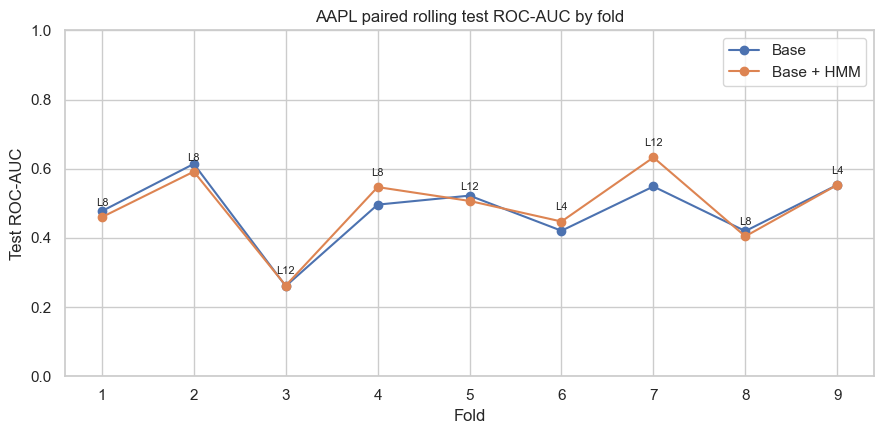

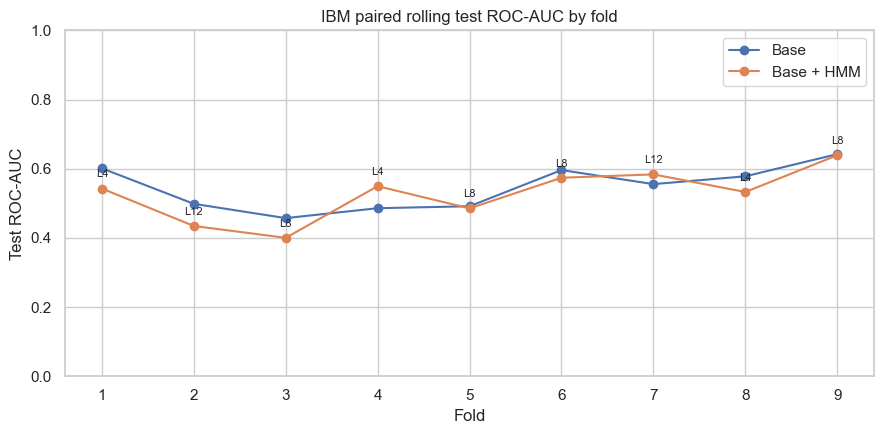

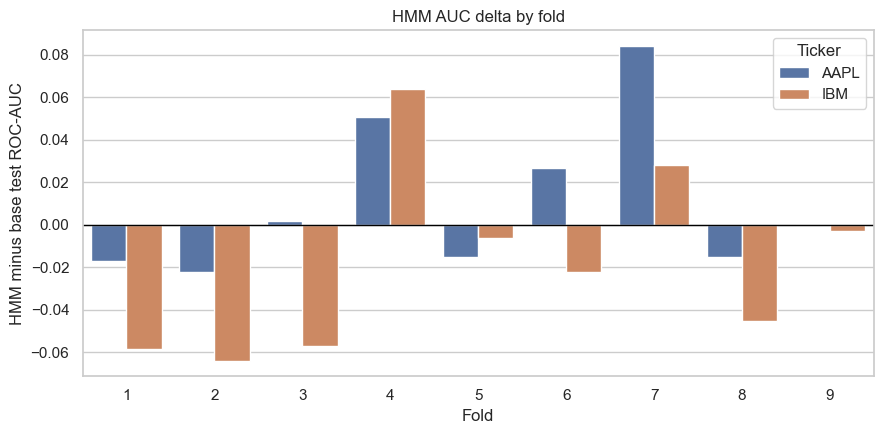

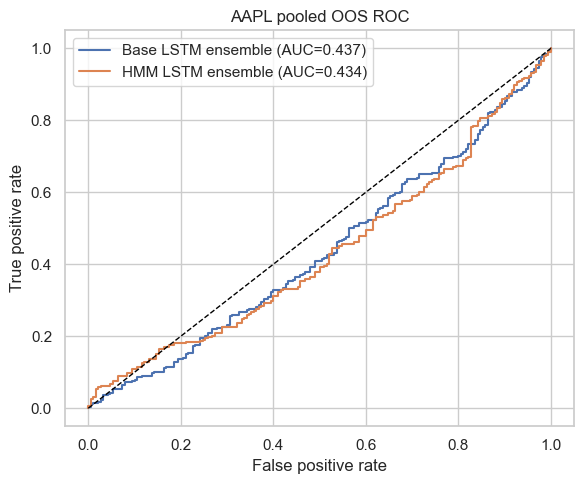

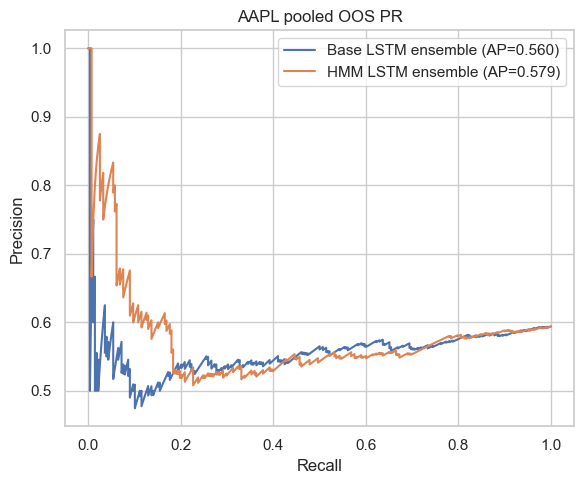

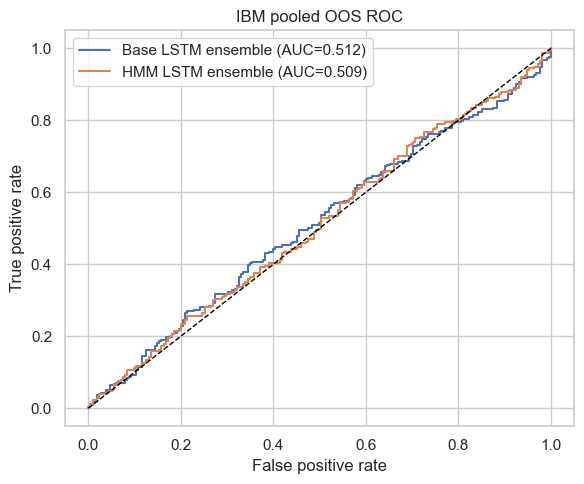

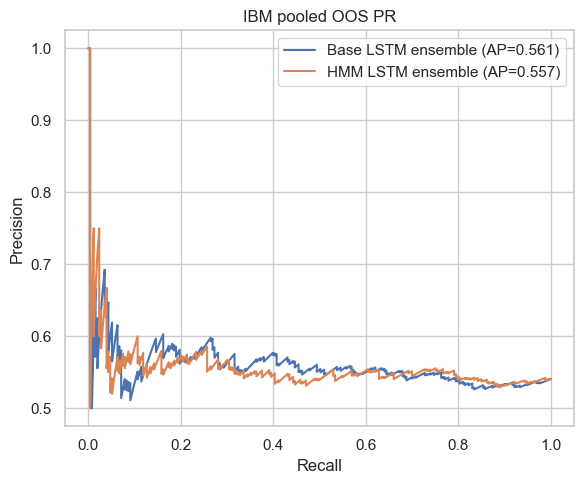

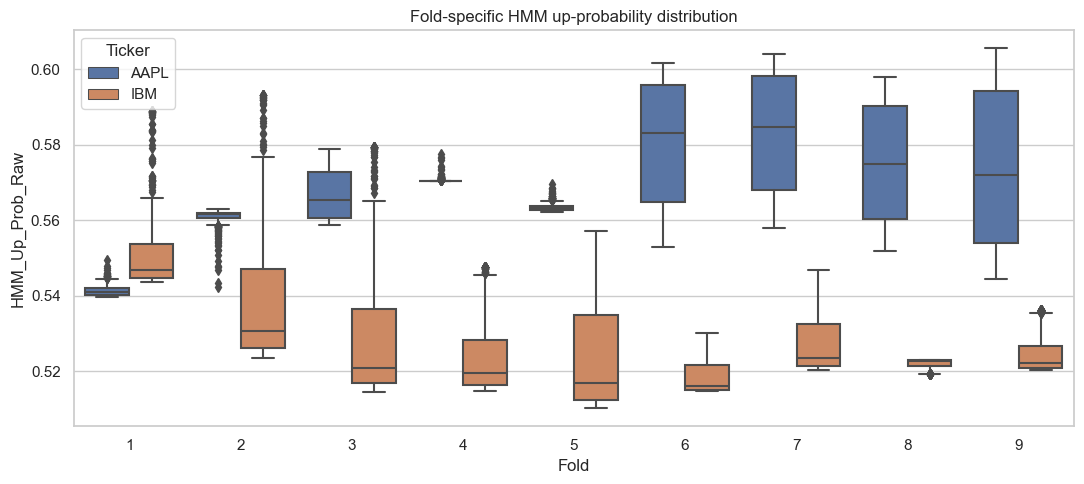

OptionError: No such keys(s): 'mode.use_inf_as_na'

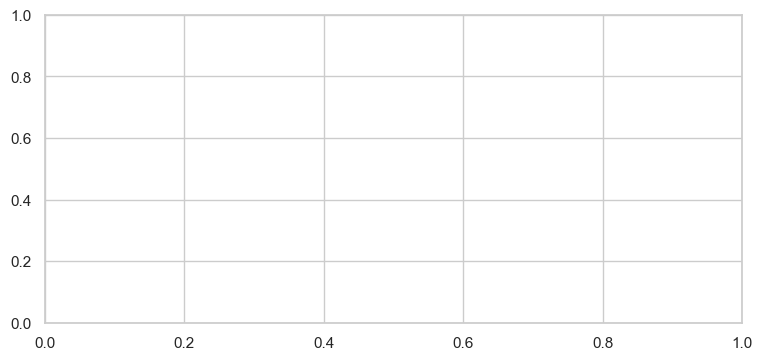

In [13]:
def save_fig(name: str) -> None:
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()


for ticker, filename in [("AAPL", "aapl_paired_rolling_auc_by_fold.png"), ("IBM", "ibm_paired_rolling_auc_by_fold.png")]:
    plot_df = rolling_paired_hmm_auc_deltas.loc[rolling_paired_hmm_auc_deltas["Ticker"].eq(ticker)].copy()
    plt.figure(figsize=(9, 4.5))
    plt.plot(plot_df["Fold"], plot_df["Base_Test_ROC_AUC"], marker="o", label="Base")
    plt.plot(plot_df["Fold"], plot_df["HMM_Test_ROC_AUC"], marker="o", label="Base + HMM")
    for row in plot_df.itertuples(index=False):
        plt.annotate(f"L{row.Selected_Lookback}", (row.Fold, row.HMM_Test_ROC_AUC), textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
    plt.title(f"{ticker} paired rolling test ROC-AUC by fold")
    plt.xlabel("Fold")
    plt.ylabel("Test ROC-AUC")
    plt.ylim(0, 1)
    plt.legend()
    save_fig(filename)

plt.figure(figsize=(9, 4.5))
sns.barplot(data=rolling_paired_hmm_auc_deltas, x="Fold", y="Delta_HMM_AUC", hue="Ticker", palette=ticker_colors)
plt.axhline(0, color="black", linewidth=1)
plt.title("HMM AUC delta by fold")
plt.ylabel("HMM minus base test ROC-AUC")
save_fig("paired_hmm_auc_delta_by_fold.png")

for ticker in TICKERS:
    pooled = rolling_oos_predictions.loc[
        (rolling_oos_predictions["Ticker"].eq(ticker))
        & (rolling_oos_predictions["Model"].isin(["Base LSTM ensemble", "HMM LSTM ensemble"]))
    ]
    plt.figure(figsize=(6, 5))
    for model_name in ["Base LSTM ensemble", "HMM LSTM ensemble"]:
        pred = pooled.loc[pooled["Model"].eq(model_name)]
        fpr, tpr, _ = roc_curve(pred["Target_State_Binary"].astype(int), pred["Predicted_Probability_Up"].astype(float))
        auc_value = roc_auc_score(pred["Target_State_Binary"].astype(int), pred["Predicted_Probability_Up"].astype(float))
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={auc_value:.3f})")
    plt.plot([0, 1], [0, 1], linestyle="--", color="black", linewidth=1)
    plt.xlabel("False positive rate")
    plt.ylabel("True positive rate")
    plt.title(f"{ticker} pooled OOS ROC")
    plt.legend()
    save_fig(f"pooled_oos_roc_{ticker.lower()}.png")

    plt.figure(figsize=(6, 5))
    for model_name in ["Base LSTM ensemble", "HMM LSTM ensemble"]:
        pred = pooled.loc[pooled["Model"].eq(model_name)]
        precision, recall, _ = precision_recall_curve(pred["Target_State_Binary"].astype(int), pred["Predicted_Probability_Up"].astype(float))
        ap_value = average_precision_score(pred["Target_State_Binary"].astype(int), pred["Predicted_Probability_Up"].astype(float))
        plt.plot(recall, precision, label=f"{model_name} (AP={ap_value:.3f})")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(f"{ticker} pooled OOS PR")
    plt.legend()
    save_fig(f"pooled_oos_pr_{ticker.lower()}.png")

hmm_distribution_frames = []
for (ticker, fold), df in prepared_fold_data.items():
    tmp = df[["Ticker", "Fold_Split", "HMM_Up_Prob_Raw"]].copy()
    tmp["Fold"] = fold
    hmm_distribution_frames.append(tmp)
hmm_distribution_df = pd.concat(hmm_distribution_frames, ignore_index=True)
plt.figure(figsize=(11, 5))
sns.boxplot(data=hmm_distribution_df, x="Fold", y="HMM_Up_Prob_Raw", hue="Ticker", palette=ticker_colors)
plt.title("Fold-specific HMM up-probability distribution")
plt.ylabel("HMM_Up_Prob_Raw")
save_fig("rolling_hmm_probability_distribution_by_fold.png")

plt.figure(figsize=(9, 4))
lookback_plot = rolling_validation_lookback_selection.loc[rolling_validation_lookback_selection["Selected"]].copy()
sns.lineplot(data=lookback_plot, x="Fold", y="Lookback", hue="Ticker", palette=ticker_colors, marker="o")
plt.yticks(LOOKBACK_GRID)
plt.title("Selected paired lookback by fold")
save_fig("selected_lookback_by_fold.png")

plt.figure(figsize=(12, 5))
comparison_df = rolling_fold_model_results.copy()
sns.barplot(data=comparison_df, x="Ticker", y="Test_ROC_AUC", hue="Model")
plt.ylim(0, 1)
plt.title("Contextual baseline comparison")
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5), fontsize=8)
save_fig("contextual_baseline_comparison.png")


## Run metadata


In [14]:
metadata = {
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "input_source_file_paths": {
        "weekly_unscaled": str(WEEKLY_SOURCE_PATH.relative_to(PROJECT_ROOT)),
        "vol_context_unscaled": str(VOL_CONTEXT_SOURCE_PATH.relative_to(PROJECT_ROOT)),
        "weekly_scaled_not_used": str(WEEKLY_SCALED_PATH_FORBIDDEN.relative_to(PROJECT_ROOT)),
    },
    "fold_settings": {
        "INITIAL_TRAIN_WEEKS": INITIAL_TRAIN_WEEKS,
        "VALIDATION_WEEKS": VALIDATION_WEEKS,
        "TEST_WEEKS": TEST_WEEKS,
        "STEP_WEEKS": STEP_WEEKS,
    },
    "seeds": SEEDS,
    "lookback_grid": LOOKBACK_GRID,
    "architecture": {
        "lstm_units": list(LSTM_CONFIG.lstm_units),
        "dense_units": list(LSTM_CONFIG.dense_units),
        "dropout": LSTM_CONFIG.dropout,
        "recurrent_dropout": LSTM_CONFIG.recurrent_dropout,
        "learning_rate": LSTM_CONFIG.learning_rate,
        "MAX_EPOCHS": MAX_EPOCHS,
        "BATCH_SIZE": BATCH_SIZE,
        "class_weight": None,
        "shuffle": True,
    },
    "model_variants": VARIANT_FEATURES,
    "feature_lists": {
        "technical_features": TECHNICAL_FEATURES,
        "vol_context_features_compact": VOL_CONTEXT_FEATURES_COMPACT,
    },
    "leakage_control_decisions": [
        "Use unscaled weekly modelling dataframe, not fixed-split scaled weekly data.",
        "Merge only unscaled VIX/VXN context columns needed for AAPL.",
        "Refit HMM separately for every ticker and rolling fold.",
        "Fit all scalers using fold training rows only.",
        "Estimate HMM state-up rates using fold training labels only.",
        "Use validation only for lookback, threshold, and logistic C selection.",
        "Use test outcomes only after paired lookback selection is complete.",
        "Exclude QQQ, QQQ-relative, NBER, macro, smoothed HMM, and HMM_Bullish_Prob_Next columns.",
    ],
}
with open(OUTPUT_DIR / "rolling_run_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)
print("Saved metadata:", OUTPUT_DIR / "rolling_run_metadata.json")


Saved metadata: D:\BA_year_3\honour project\outputs\weekly_rolling_hmm_replication_aapl_ibm\rolling_run_metadata.json


## Ending note

This notebook produced rolling fold definitions, fold-level model results, paired HMM deltas, pooled out-of-sample predictions, and rolling figures for AAPL and IBM. AAPL and IBM use slightly different base feature sets, so conclusions are ticker-specific. Mean fold AUC and pooled AUC answer different questions: the first gives every fold equal weight, while the second ranks all out-of-sample predictions together. Any sign-flip interpretation is limited by the nine folds and should be read cautiously rather than as definitive proof.


## Final sanity checks


In [15]:
REQUIRED_OUTPUTS = [
    OUTPUT_DIR / "rolling_fold_definitions.csv",
    OUTPUT_DIR / "rolling_feature_audit.csv",
    OUTPUT_DIR / "rolling_feature_scaling_diagnostics.csv",
    OUTPUT_DIR / "rolling_hmm_fold_diagnostics.csv",
    OUTPUT_DIR / "rolling_sequence_diagnostics.csv",
    OUTPUT_DIR / "rolling_lstm_seed_validation_results.csv",
    OUTPUT_DIR / "rolling_validation_lookback_selection.csv",
    OUTPUT_DIR / "rolling_fold_model_results.csv",
    OUTPUT_DIR / "rolling_paired_hmm_auc_deltas.csv",
    OUTPUT_DIR / "rolling_paired_hmm_summary.csv",
    OUTPUT_DIR / "rolling_oos_predictions.csv",
    OUTPUT_DIR / "rolling_contextual_baseline_results.csv",
    OUTPUT_DIR / "rolling_run_metadata.json",
    FIGURE_DIR / "aapl_paired_rolling_auc_by_fold.png",
    FIGURE_DIR / "ibm_paired_rolling_auc_by_fold.png",
    FIGURE_DIR / "paired_hmm_auc_delta_by_fold.png",
    FIGURE_DIR / "pooled_oos_roc_aapl.png",
    FIGURE_DIR / "pooled_oos_roc_ibm.png",
    FIGURE_DIR / "pooled_oos_pr_aapl.png",
    FIGURE_DIR / "pooled_oos_pr_ibm.png",
    FIGURE_DIR / "rolling_hmm_probability_distribution_by_fold.png",
    FIGURE_DIR / "selected_lookback_by_fold.png",
    FIGURE_DIR / "contextual_baseline_comparison.png",
]


def assert_protected_sources_unchanged() -> None:
    changed = []
    for path in PROTECTED_SOURCE_PATHS:
        rel = str(path.relative_to(PROJECT_ROOT))
        current = {"size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
        if current != protected_source_state[rel]:
            changed.append({"path": rel, "start": protected_source_state[rel], "current": current})
    if changed:
        raise RuntimeError(f"Protected source files changed during this run: {changed}")


def assert_existing_outputs_unchanged() -> None:
    changed = []
    for rel, start_state in existing_output_state.items():
        path = PROJECT_ROOT / rel
        if not path.exists():
            changed.append({"path": rel, "issue": "missing"})
            continue
        current = {"size": path.stat().st_size, "mtime_ns": path.stat().st_mtime_ns}
        if current != start_state:
            changed.append({"path": rel, "start": start_state, "current": current})
    if changed:
        raise RuntimeError(f"Existing output files outside the new output directory changed: {changed[:10]}")


assert_protected_sources_unchanged()
assert_existing_outputs_unchanged()

if sorted(rolling_fold_model_results["Ticker"].unique().tolist()) != TICKERS:
    raise RuntimeError("Models were evaluated for tickers other than AAPL and IBM.")
all_model_features = [feature for features in VARIANT_FEATURES.values() for feature in features]
if any(token.lower() in feature.lower() for token in ["QQQ", "Relative_", "NBER", "Macro"] for feature in all_model_features):
    raise RuntimeError("A QQQ, QQQ-relative, NBER, or macro feature entered a model.")
if any(feature == "HMM_Bullish_Prob_Next" or "Smoothed" in feature for feature in all_model_features):
    raise RuntimeError("A forbidden HMM feature entered a model.")
if not rolling_hmm_fold_diagnostics["HMM_Fitted_On"].eq("fold_train_only").all():
    raise RuntimeError("At least one HMM was not refitted by fold using training rows only.")
if not rolling_feature_scaling_diagnostics["Scaler_Fitted_On"].eq("fold_train_only").all():
    raise RuntimeError("At least one scaler was not fitted using fold training rows only.")
if not rolling_hmm_fold_diagnostics["State_Up_Rates_Estimated_On"].eq("fold_train_labels_only").all():
    raise RuntimeError("At least one HMM state-up mapping was not estimated from fold training labels only.")
if not rolling_validation_lookback_selection.groupby(["Ticker", "Fold"])["Selected"].sum().eq(1).all():
    raise RuntimeError("Each ticker/fold must have exactly one selected lookback.")
if rolling_fold_definitions.duplicated(["Ticker", "Test_Start_Date", "Test_End_Date"]).any():
    raise RuntimeError("Duplicate test fold date ranges found.")

missing = [str(path.relative_to(PROJECT_ROOT)) for path in REQUIRED_OUTPUTS if not path.exists()]
if missing:
    raise FileNotFoundError(f"Required outputs are missing: {missing}")

checklist = [
    "no existing source files were modified",
    "only AAPL and IBM were evaluated",
    "no QQQ, QQQ-relative, NBER, macro, or MSFT-specific features were used",
    "no HMM_Bullish_Prob_Next or smoothed HMM features were used",
    "every HMM was refitted separately by ticker and rolling fold",
    "every scaler was fitted only on that fold's training rows",
    "every HMM state-up mapping used only that fold's training labels",
    "all lookback, threshold, and logistic-C choices used validation only",
    "no test result was used to choose a model configuration",
    "all test blocks are non-overlapping",
    "all required outputs exist",
]
print("Final sanity checklist:")
for item in checklist:
    print(f"[x] {item}")
print("Rolling AAPL and IBM paired HMM replication completed successfully.")


RuntimeError: Protected source files changed during this run: [{'path': 'weekly_controlled_hmm_lstm_comparison.ipynb', 'start': {'size': 790365, 'mtime_ns': 1783042052716866500}, 'current': {'size': 790365, 'mtime_ns': 1783473140833160300}}]